# Lab 4: EEG Seizure Detection Using Wavelet Images and CNN

## Objective

The goal of this lab is to classify EEG recordings into two classes: **seizure** and **non-seizure**. The solution uses EEG time-series recordings from the CHB-MIT database, converts selected EEG segments into wavelet scalogram images, and classifies those images with a convolutional neural network (CNN).

The heavy workflow has already been completed in this project folder. This notebook is a clean submission notebook that verifies and demonstrates the existing artifacts without downloading EDF files, regenerating images, or retraining the model by default.

## Imports

Only lightweight imports needed for verification, visualization, loading the trained CNN, and running a small prediction demo are used below.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model

warnings.filterwarnings('ignore')
np.random.seed(42)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.1


## Project Paths

All paths are relative to the notebook location, so the notebook can be run from the project root without hard-coded absolute paths.

In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw' / 'chbmit'
PROCESSED_DIR = DATA_DIR / 'processed'
WAVELET_DIR = PROCESSED_DIR / 'wavelet_images'
SEIZURE_IMG_DIR = WAVELET_DIR / 'seizure'
NON_SEIZURE_IMG_DIR = WAVELET_DIR / 'non_seizure'
MODELS_DIR = PROJECT_DIR / 'models'
MODEL_PATH = MODELS_DIR / 'eeg_seizure_cnn.h5'
METRICS_PATH = MODELS_DIR / 'eeg_seizure_metrics.json'

paths = {
    'PROJECT_DIR': PROJECT_DIR,
    'RAW_DIR': RAW_DIR,
    'WAVELET_DIR': WAVELET_DIR,
    'SEIZURE_IMG_DIR': SEIZURE_IMG_DIR,
    'NON_SEIZURE_IMG_DIR': NON_SEIZURE_IMG_DIR,
    'MODEL_PATH': MODEL_PATH,
    'METRICS_PATH': METRICS_PATH,
}

for name, path in paths.items():
    print(f'{name}: {path}')

PROJECT_DIR: d:\Master\second year\second\AI\labs\Lab4
RAW_DIR: d:\Master\second year\second\AI\labs\Lab4\data\raw\chbmit
WAVELET_DIR: d:\Master\second year\second\AI\labs\Lab4\data\processed\wavelet_images
SEIZURE_IMG_DIR: d:\Master\second year\second\AI\labs\Lab4\data\processed\wavelet_images\seizure
NON_SEIZURE_IMG_DIR: d:\Master\second year\second\AI\labs\Lab4\data\processed\wavelet_images\non_seizure
MODEL_PATH: d:\Master\second year\second\AI\labs\Lab4\models\eeg_seizure_cnn.h5
METRICS_PATH: d:\Master\second year\second\AI\labs\Lab4\models\eeg_seizure_metrics.json


## Dataset Description

The CHB-MIT Scalp EEG Database from PhysioNet was used as the source dataset. The full database is large, so only the required subset was downloaded earlier: **50 EEG recordings with seizures** and **50 EEG recordings without seizures**.

This notebook uses the already downloaded local files and the already generated wavelet images. It does not download from PhysioNet during normal execution.

## Existing Dataset Verification

The lab requires at least 50 seizure examples and 50 non-seizure examples. The following cell counts the existing wavelet PNG files and checks that the prepared dataset satisfies this requirement.

In [3]:
seizure_images = sorted(SEIZURE_IMG_DIR.glob('*.png'))
non_seizure_images = sorted(NON_SEIZURE_IMG_DIR.glob('*.png'))

print(f'Seizure wavelet images:     {len(seizure_images)}')
print(f'Non-seizure wavelet images: {len(non_seizure_images)}')

if len(seizure_images) == 50 and len(non_seizure_images) == 50:
    print('Dataset verification passed: 50 seizure and 50 non-seizure images are available.')
else:
    print('Warning: expected exactly 50 images in each class. Please check the processed dataset folders.')

assert MODEL_PATH.exists(), f'Missing trained model: {MODEL_PATH}'
assert METRICS_PATH.exists(), f'Missing metrics file: {METRICS_PATH}'

Seizure wavelet images:     50
Non-seizure wavelet images: 50
Dataset verification passed: 50 seizure and 50 non-seizure images are available.


## Metadata and Download Notes

The EDF files were downloaded earlier with the robust PowerShell script `download_edf_files.ps1`. The script uses `curl.exe` with resume mode (`-C -`) and retry options, and it downloads from the public PhysioNet S3 mirror instead of downloading the full CHB-MIT archive.

The script is **not executed** in this notebook. It remains in the project folder only as documentation and as a reproducibility helper if the raw data ever needs to be restored.

Example command used outside this notebook:

```powershell
powershell -ExecutionPolicy Bypass -File .\download_edf_files.ps1
```

## Optional Heavy Pipeline Flags

The following flags document the heavy stages. They are intentionally disabled so that `Run All` only verifies and demonstrates existing artifacts.

In [4]:
RUN_DOWNLOAD = False
RUN_PREPROCESSING = False
RUN_TRAINING = False

print('RUN_DOWNLOAD:', RUN_DOWNLOAD)
print('RUN_PREPROCESSING:', RUN_PREPROCESSING)
print('RUN_TRAINING:', RUN_TRAINING)
print('Heavy pipeline steps are disabled by default.')

RUN_DOWNLOAD: False
RUN_PREPROCESSING: False
RUN_TRAINING: False
Heavy pipeline steps are disabled by default.


## Wavelet Preprocessing Summary

The preprocessing stage was already completed before this notebook was finalized:

1. EDF files were read using MNE.
2. Seizure start and end times were extracted from CHB-MIT patient summary files.
3. For seizure recordings, a segment was cut from inside the annotated seizure interval.
4. For non-seizure recordings, a segment was cut from a recording without an annotated seizure.
5. A continuous wavelet transform was applied with PyWavelets.
6. The resulting scalograms were saved as PNG images in:
   - `data/processed/wavelet_images/seizure`
   - `data/processed/wavelet_images/non_seizure`

## Sample Wavelet Images

The next cell displays examples from both classes. These images are the actual inputs used by the CNN.

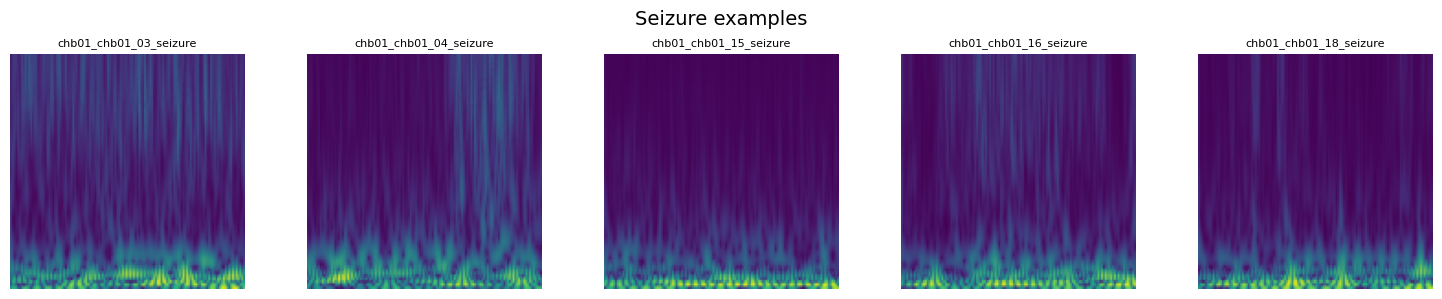

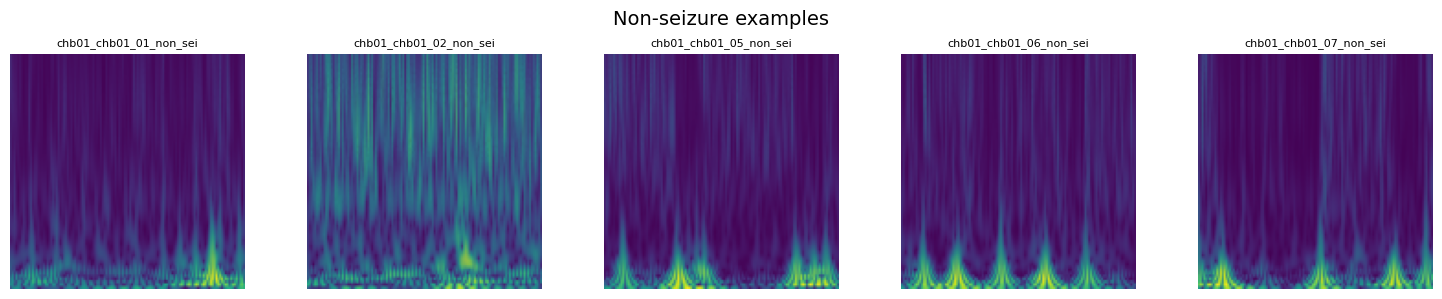

In [5]:
def show_examples(image_paths, title, max_images=5):
    selected = image_paths[:max_images]
    fig, axes = plt.subplots(1, len(selected), figsize=(3 * len(selected), 3))
    if len(selected) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=14)
    for ax, path in zip(axes, selected):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(path.stem[:22], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_examples(seizure_images, 'Seizure examples')
show_examples(non_seizure_images, 'Non-seizure examples')

## Model Architecture

A convolutional neural network was trained on the generated wavelet scalogram images. The model contains three convolution/max-pooling blocks, followed by a dense layer, dropout, and a sigmoid output neuron for binary classification.

Training was performed on CPU with TensorFlow/Keras. This notebook loads the already trained model and does not retrain it by default.

## Load the Trained Model

The trained CNN is stored in `models/eeg_seizure_cnn.h5`.

In [6]:
model = load_model(MODEL_PATH)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 64)       0

## Load Saved Metrics

The metrics JSON stores the final evaluation results from the completed training run.

In [7]:
with METRICS_PATH.open('r', encoding='utf-8') as f:
    metrics = json.load(f)

print('Available metric keys:')
for key in metrics.keys():
    print('-', key)

n_train = metrics.get('n_train')
n_test = metrics.get('n_test')
test_accuracy = metrics.get('test_accuracy')
test_loss = metrics.get('test_loss')
confusion_matrix = np.array(metrics.get('confusion_matrix', []))
class_names = metrics.get('class_names', ['non_seizure', 'seizure'])

print('\nFinal results')
if n_train is not None and n_test is not None:
    print(f'Train/Test split: {n_train} / {n_test}')
if test_accuracy is not None:
    print(f'Test accuracy: {test_accuracy:.4f}')
if test_loss is not None:
    print(f'Test loss: {test_loss:.4f}')
if confusion_matrix.size:
    print('Confusion matrix:')
    print(confusion_matrix)

if 'classification_report_text' in metrics:
    print('\nClassification report:')
    print(metrics['classification_report_text'])

Available metric keys:
- created_at
- test_loss
- test_accuracy
- class_names
- confusion_matrix
- classification_report_text
- classification_report
- n_train
- n_test
- model_path

Final results
Train/Test split: 80 / 20
Test accuracy: 0.7500
Test loss: 0.5398
Confusion matrix:
[[6 4]
 [1 9]]

Classification report:
              precision    recall  f1-score   support

 non_seizure       0.86      0.60      0.71        10
     seizure       0.69      0.90      0.78        10

    accuracy                           0.75        20
   macro avg       0.77      0.75      0.74        20
weighted avg       0.77      0.75      0.74        20



## Results Visualization

The metrics file contains the final evaluation metrics and confusion matrix. Full epoch-by-epoch training history was not stored in the JSON file, so this notebook visualizes the final confusion matrix only.

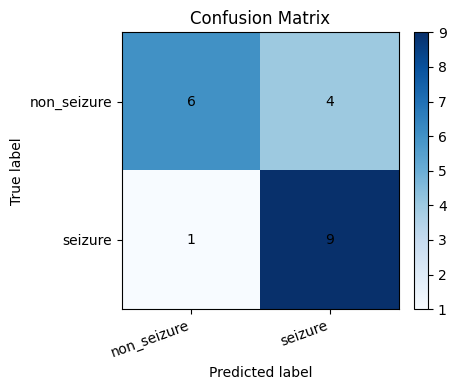

Training history curves are not available because only final metrics were saved.


In [8]:
if confusion_matrix.size:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(confusion_matrix, cmap='Blues')
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=20, ha='right')
    ax.set_yticklabels(class_names)

    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            ax.text(j, i, int(confusion_matrix[i, j]), ha='center', va='center', color='black')

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('No confusion matrix found in the metrics file.')

if 'history' not in metrics:
    print('Training history curves are not available because only final metrics were saved.')

## Optional Prediction Demo

The following cell runs the trained model on a few existing wavelet images from each class. It does not require any external data and does not modify the dataset.

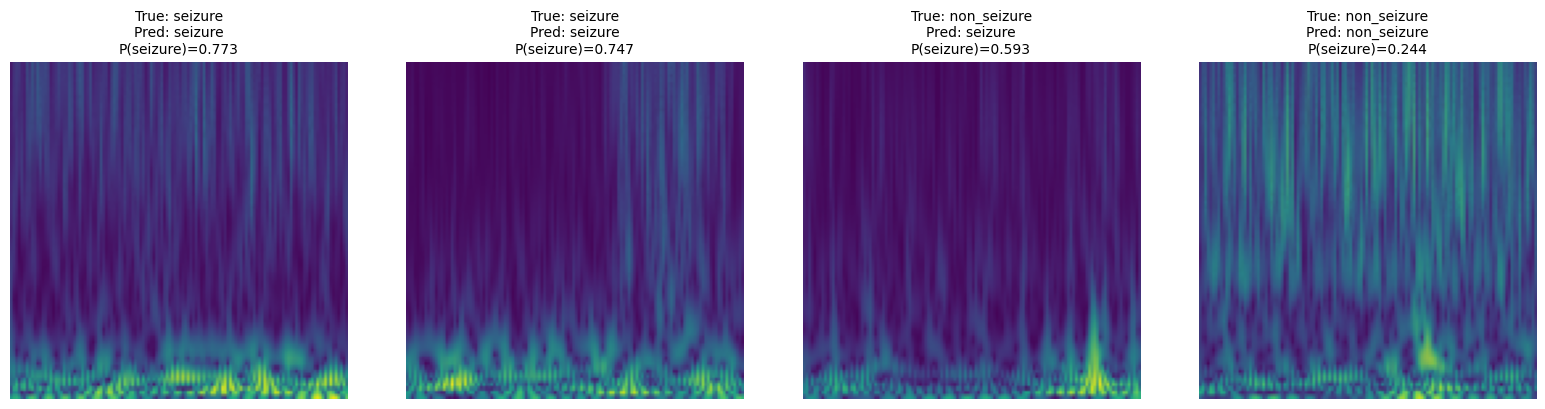

In [9]:
def model_image_size(model):
    shape = model.input_shape
    return int(shape[1]), int(shape[2])

IMG_HEIGHT, IMG_WIDTH = model_image_size(model)

def load_image_for_model(path):
    img = tf.keras.utils.load_img(path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    arr = tf.keras.utils.img_to_array(img) / 255.0
    return arr

# Use two examples from each class for a compact demo.
demo_paths = seizure_images[:2] + non_seizure_images[:2]
true_labels = ['seizure'] * 2 + ['non_seizure'] * 2
batch = np.stack([load_image_for_model(path) for path in demo_paths])
probabilities = model.predict(batch, verbose=0).ravel()

fig, axes = plt.subplots(1, len(demo_paths), figsize=(4 * len(demo_paths), 4))
for ax, path, true_label, probability in zip(axes, demo_paths, true_labels, probabilities):
    predicted_label = 'seizure' if probability >= 0.5 else 'non_seizure'
    ax.imshow(Image.open(path))
    ax.set_title(
        f'True: {true_label}\nPred: {predicted_label}\nP(seizure)={probability:.3f}',
        fontsize=10,
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

## Conclusion

This project prepared **100 wavelet scalogram images** from CHB-MIT EEG recordings: 50 seizure examples and 50 non-seizure examples. A CNN was trained on these images and saved as `models/eeg_seizure_cnn.h5`.

The saved evaluation results show a train/test split of **80 / 20**, a test accuracy of **0.75**, a test loss of **0.5398**, and a confusion matrix of `[[6, 4], [1, 9]]`.

For a small educational dataset, these results are acceptable as a baseline demonstration of EEG seizure detection using wavelet images and a CNN. Better performance would require more samples, patient-aware splitting, hyperparameter tuning, and more rigorous validation.